In [1]:
import os
os.chdir('..')

In [2]:
from thefuzz import process
import cn2an
import logging
import re
from utils import pre_process, pre_process_without_n, printWithColor, standerlize_一般政策性内容
from extraction import find_一般政策语言_rule_base
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['Heiti TC']  

/Users/ender_yang/opt/anaconda3/envs/lainchain/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def find_设置特定目标_rule_base(docs, 一般政策语言):
     # Ignore the warnings
    logging.getLogger().setLevel(logging.ERROR)
    
    # We need to standardize the 一般政策性内容 to avoid any characters at the beginning of the sentence
    一般政策语言 = standerlize_一般政策性内容(一般政策语言)

    # Define keywords for regular expression
    keywords = [
        "(?:^|,)\s*第.*?(章|节|点|条).*?(目标|工作目标|工作重点|发展目标|明确目标|重点目标|重要目标|目标任务|任务|重点任务|主要任务|具体要求|工作要求|主要要求)"
    ]
    rule_1_pattern = re.compile('|'.join(keywords))
    rule_3_pattern = ["推动.*?目标", "在.*?方面实行", "总则","实现","达到","解决","确保","保证","保障"]
    rule_3_pattern = re.compile('|'.join(rule_3_pattern))
    
    paragraphs = pre_process(docs)
    matched_paragraphs = []
    
    # First loop: Search for matches in each paragraph
    for paragraph in paragraphs:
        check_paragraph = re.sub(r'\s+', '', paragraph)
        if any(sentence in check_paragraph for sentence in 一般政策语言):
            continue
        if rule_1_pattern.search(paragraph):
            matched_paragraphs.append((paragraph.strip(), rule_1_pattern.search(paragraph).group()))
        elif rule_3_pattern.search(paragraph):
            matched_paragraphs.append((paragraph.strip(), rule_3_pattern.search(paragraph).group()))
    
    # Find the indices of matched paragraphs in the original document         
    matched_paragraphs_index = []
    for sentence in matched_paragraphs:
        begin_index = docs.find(sentence[0])
        end_index = begin_index + len(sentence[0])
        matched_paragraphs_index.append((begin_index, end_index))
        
    return matched_paragraphs, matched_paragraphs_index

## Demonstration for using find_设置特定目标_rule_base() function ##

$\textbf{We first read .txt file randomly from samples folder}$

In [4]:
file_sample = os.listdir('sample')[20]
docs = open(f'sample/{file_sample}', 'r').read()

$\textbf{Since we need 一般政策性内容 content, so we first extract 一般政策性内容}$

In [5]:
def get_一般政策语言(docs):
    matched_paragraphs_一般政策语言, _ = find_一般政策语言_rule_base(docs)
    一般政策语言_list = []
    for 一般政策语言, _ in matched_paragraphs_一般政策语言:
        一般政策语言_list += [一般政策语言]
        
    return 一般政策语言_list

In [6]:
# we can check the 一般政策语言 content
一般政策语言_list = get_一般政策语言(docs)
print(一般政策语言_list)

['为进一步规范我市医疗废物收集、转运和处置等个环节的环境管理，提高污染防治水平，维护我市环境安全，保护人民群众身体健康']


## Now we can call the function find_设置特定目标_rule_base() ##

In [7]:
matched_paragraphs, matched_paragraphs_index = find_设置特定目标_rule_base(docs, 一般政策语言_list)

$\textbf{We can now check the content that we retrieved from the file and its corresponding reasons.}$

In [8]:
pd.set_option('display.max_colwidth', None)
df = pd.DataFrame(matched_paragraphs, columns=['Retrieve Info', 'Reason'])
df.head(10)

,Retrieve Info,Reason
0,到2015年，全面实施医疗机构医疗废物全覆盖的安全收集、转运、处置体系，有效遏制医疗废物引发的环境突发事件，实现各级医疗机构医疗废物收集、转运、处置规范化合格管理，实现医疗废物处置率达到100%,实现
1,为确保银川市医疗废物集中收集和无害化处置工作顺利开展并取得实质性的成效，建立医疗废物环境监管长效机制，经研究决定成立银川市医疗废物集中收集和无害化处置工作领导小组,确保
2,（五）联合卫生等部门加大对突发疫情和突发事件应对能力的培训、演练，尤其是对乡镇卫生医疗机构应急能力的培训工作，确保突发疫情和突发事件医疗废物的规范化处置,确保
3,（三）各辖区要确保申报登记全面属实、核定全面准确、收运合法规范、处置安全可靠，将该项工作抓紧、抓实、抓出成效，建立准确的医疗废物管理数据库和规范的环境监督监管体系,确保
4,收集、转运单位要保证至少2天到乡镇以上卫生、医疗机构收运一次医疗废物，并保证当天运送到处置单位，且严格执行转移联单制度,保证
5,（五）各辖区要将对医疗废物的管理纳入长效管理机制，对影响群众身体健康和环境安全的问题，要及时查处和解决，市局将依照相关规定要求，把医疗废物规范化管理纳入年度重点工作进行考核，并将完成考核情况进行通报,解决


$\textbf{We can also check where is the sentence}$

In [9]:
printWithColor(docs, matched_paragraphs_index)

    【法宝引证码】 CLI.12.6810956
原文链接：https://www.pkulaw.com/lar/0c1e2d81515da7526a171e371208a23fbdfb.html
银川市环境保护局关于进一步加强银川市医疗废物集中收集和无害化处置工作实施方案
银川市环境保护局关于进一步加强银川市医疗废物集中收集和无害化处置工作实施方案
银环保发〔2012〕373号
两县一市环保局、三区分局：
　　为进一步规范我市医疗废物收集、转运和处置等个环节的环境管理，提高污染防治水平，维护我市环境安全，保护人民群众身体健康。根据自治区人民政府办公厅《关于加强医疗废物集中收集和无害化处理意见》的通知（宁政发【2012】148号）和自治区环保厅办公室《关于进一步加强全区医疗废物集中收集和无害化处置工作的通知》（宁环办发【2012】137号）的部署和要求，特制定本实施方案，望认真贯彻执行。
　　一、总体目标
　　2012年底，银川市人民政府与自治区环保厅签订新一轮银川市医疗废物集中处置框架性协议，银川市荣洁生活固体废物处理处置有限公司与自治区危险废物和医疗废物处置中心签订专业集中转运、处置协议。在已开展乡镇医疗机构集中收集、转运的基础上，大力推广和普及集中收运工作，2012年底建立乡镇以上医疗机构较为完善的集中收集、转运体系。到2015年，全面实施医疗机构医疗废物全覆盖的安全收集、转运、处置体系，有效遏制医疗废物引发的环境突发事件，实现各级医疗机构医疗废物收集、转运、处置规范化合格管理，实现医疗废物处置率达到100%。
　　二、组织领导
　　为确保银川市医疗废物集中收集和无害化处置工作顺利开展并取得实质性的成效，建立医疗废物环境监管长效机制，经研究决定成立银川市医疗废物集中收集和无害化处置工作领导小组。
　　组长：白治彪银川市环保局调研员
　　副组长：蔡懿平银川市固体废物处理监察大队队长
　　成员：楚京彬王辉高晓杰王惠娟伍永琪
　　王勇杨立忠刘建武张晓东杨学军
　　领导小组下设办公室，办公室设在银川市固体废物处理监察大队，具体负责年度医疗废物预报表汇总上报、协调对医疗废转运、处置单位相关培训、资质办理、各有关部门对银川市医疗废物检查、考核及其它相关协调工作。
　　三、工作任务
　　（一）认真贯彻落实自治区人民政府办公厅《关于加强医疗废物集中收集和无害化处理意见》（

## Now we can run batch processing on our sample data ##

In [10]:
def run_batch(path_to_folder):
    return_df = pd.DataFrame(columns=['filename', 'Retrieve Info', 'Reason', 'Original Text Length','Retrieve Info Length', '一般政策语言'])
    files = os.listdir(path_to_folder)
    for file in files:
        if not file.endswith('.txt'):
            continue
        docs = open(f'{path_to_folder}/{file}', 'r').read()
        一般政策语言_list = get_一般政策语言(docs)
        
        matched_paragraphs, matched_paragraphs_index = find_设置特定目标_rule_base(docs, 一般政策语言_list)
        matched_paragraphs_list = "\n".join([paragraph[0] for paragraph in matched_paragraphs])
        reson_list = "\n".join([paragraph[1] for paragraph in matched_paragraphs])
        
        return_df.loc[len(return_df)] = [file, matched_paragraphs_list , reson_list, len(docs), len(matched_paragraphs_list), "\n".join(一般政策语言_list)]
    
    return return_df


In [11]:
df = run_batch('sample')
# we chack first 5 files
df.head(5)
# you can save this to csv
# df.to_csv('path/to/your/result.csv', index=False)

,filename,Retrieve Info,Reason,Original Text Length,Retrieve Info Length,一般政策语言
0,佛山市人力资源和社会保障局关于新增血友病(...(FBM-CLI.12.6305146).txt,佛山市人力资源和社会保障局关于新增血友病(凝血因子治疗)门诊特定病种等有关问题的通知\n佛山市人力资源和社会保障局关于新增血友病(凝血因子治疗)门诊特定病种等有关问题的通知\n各区人力资源和社会保障局：,保障\n保障\n保障,558,99,为进一步提高我市城镇职工基本医疗保险参保人员血友病门诊特定病种医疗保险待遇，根据《佛山市城镇职工基本医疗保险门诊特定病种管理暂行办法》（佛劳社〔2007〕1108号）和《进一步完善城镇职工基本医疗保险有关问题的意见》（佛劳社[2009]143号）的有关规定，现将我市城镇职工基本医疗保险部分门诊特定病种规定如下：
1,吉林省工业和信息化厅关于转发《工业和信息化...(FBM-CLI.12.1054681).txt,《指导意见》提出了示范基地创建工作的总体要求、主要任务、主要措施和保障机制,保障,1088,37,为了进一步推动我省示范基地的创建工作，加强对示范基地的培育、扶持和服务，现将《指导意见》转发给你们，请你们结合实际，贯彻落实好《指导意见》，为此，提出以下几点要求：
2,北京市公安局关于印发户籍派出所设立公共户工...(FBM-CLI.12.4083221).txt,为推动户籍管理工作理念和机制创新，有效解决暂不具备市内迁移条件的本市户籍人员落户问题，依据《中华人民共和国户口登记条例》、《派出所办理常住户口登记工作规范（试行）》等法规政策，北京市公安局经充分调研，在广泛征求意见基础上，决定在全市户籍派出所设立“公共户”，具体规定如下：\n（三）申请人应确保提供的证件材料真实准确，对于申请材料弄虚作假的，公安机关将取消其申请迁移事项；构成违法犯罪的，依法追究行政刑事责任\n4.申请人应确保提供的证件材料真实准确，对于申请材料弄虚作假的，公安机关将取消其申请迁移事项；构成违法犯罪的，依法追究行政刑事责任,解决\n确保\n确保,4274,269,为有效解决暂不具备市内迁移条件的本市户籍人员落户问题，经第5次市局局长办公会通过，现将《北京市公安局户籍派出所设立公共户工作规定（试行）》印发给你们，请认真贯彻执行
3,淄博市文化和旅游局对市政协十二届五次会议委...(FBM-CLI.12.5629955).txt,实现淄博市文化和旅游产业相关数据的集中汇聚与管理，为产业发展和管理奠定坚实基础和保障\n实现淄博市文化和旅游部门相关信息化系统升级与整合，全面提升政府对于文化和旅游产业的监管能力和水平，全面提升对企业和公众两个方向的服务能力和水平,实现\n实现,1298,114,贵单位提出的关于进一步加快数字文旅整合发展的建议收悉，现答复如下：
4,广西壮族自治区文化和旅游厅办公室关于印发《...(FBM-CLI.12.3014292).txt,,,613,0,为进一步提高广西特色旅游名县创建工作的科学性、针对性和可操作性，促进文化和旅游融合发展，我厅对《广西特色旅游名县创建工作管理办法》和《广西特色旅游名县评定标准与评分细则》进行了修订


$\textbf{Here we provide some statistics on the results}$

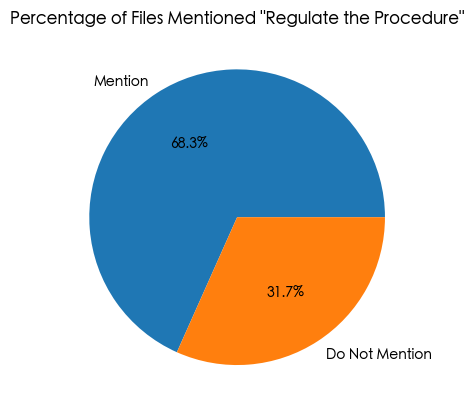

In [12]:
# We can show how many files have the retrieve info
is_mention = len(df[df['Retrieve Info'] != ''])
do_not_mention = len(df[df['Retrieve Info'] == ''])

fig, ax = plt.subplots()
ax.pie([is_mention, do_not_mention], labels=['Mention', 'Do Not Mention'], autopct='%1.1f%%')
plt.title('Percentage of Files Mentioned "Regulate the Procedure"')
plt.show()

$\textbf{To analyze the results of retrieval text, we need to remove the policy that do not have retrieval info}$

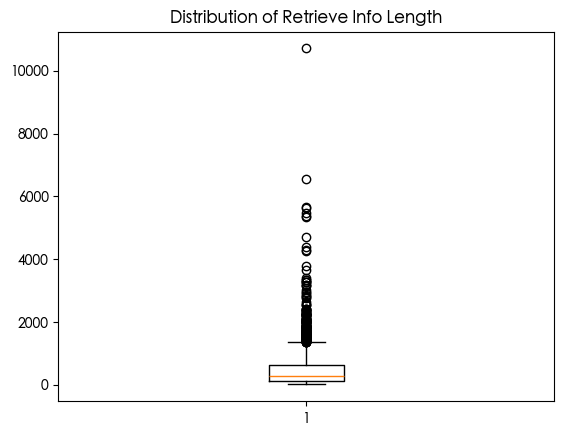

In [13]:
# Box plot to show the distribution of retrieve info length
df_temp = df.copy()
# we drop all the rows that do not have retrieve info
df_temp = df_temp[df_temp['Retrieve Info'] != '']
retrieve_info_length = df_temp['Retrieve Info'].apply(lambda x: len(x))
plt.boxplot(retrieve_info_length)
plt.title('Distribution of Retrieve Info Length')
plt.show()

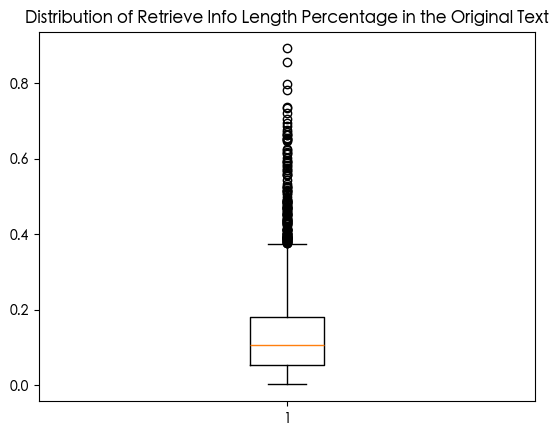

In [14]:
# we can also see the distribution that to what percentage of the document is the retrieve info
df_temp['Retrieve Info Length Percentage'] = df_temp['Retrieve Info Length'] / df_temp['Original Text Length']
plt.boxplot(df_temp['Retrieve Info Length Percentage'])
plt.title('Distribution of Retrieve Info Length Percentage in the Original Text')
plt.show()

In [15]:
# let's show the most three outliar for the retrieve info length
df_temp.sort_values('Retrieve Info Length', ascending=False).head(3)

filename  \
149   大连市人民政府关于印发大连市国民经济和社会...(FBM-CLI.12.1709530).txt   
1874  武威市人民政府办公室关于印发武威市绿色化信...(FBM-CLI.12.1669946).txt   
3321  西安市人民政府关于印发《西安市汽车产业发展...(FBM-CLI.12.2324588).txt   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [16]:
# we can also show the most three outliar for the retrieve info length percentage
df_temp.sort_values('Retrieve Info Length Percentage', ascending=False).head(3)

,filename,Retrieve Info,Reason,Original Text Length,Retrieve Info Length,一般政策语言,Retrieve Info Length Percentage
4344,宁夏回族自治区发展和改革委员会、中共宁夏区...(FBM-CLI.12.5415222).txt,宁夏回族自治区发展和改革委员会、中共宁夏区委组织部、中共宁夏区委机构编制委员会办公室、宁夏回族自治区科学技术厅、宁夏回族自治区工业和信息化厅、宁夏回族自治区公安厅、宁夏回族自治区财政厅、宁夏回族自治区人力资源和社会保障厅、宁夏回族自治区自然资源厅、宁夏回族自治区住房和城乡建设厅、宁夏回族自治区交通运输厅、宁夏回族自治区水利厅、宁夏回族自治区农业农村厅、宁夏回族自治区商务厅、宁夏回族自治区卫生健康委员会、宁夏回族自治区市场监管厅、宁夏回族自治区国有资产监督管理委员会、宁夏回族自治区公共资源交易管理局、宁夏回族自治区医疗保障局、宁夏回族自治区林业和草原局、银川海关、国家税务总局宁夏回族自治区税务局、中国人民银行银川中心支行、中国银行保险业监督管理委员会宁夏监管局、中国证券监督管理委员会宁夏监管局、中国证券监督管理委员会宁夏监管局关于印发《宁夏回族自治区公共资源交易领域严重失信主体联合惩戒实施办法(试行)》的通知\n宁夏回族自治区发展和改革委员会、中共宁夏区委组织部、中共宁夏区委机构编制委员会办公室、宁夏回族自治区科学技术厅、宁夏回族自治区工业和信息化厅、宁夏回族自治区公安厅、宁夏回族自治区财政厅、宁夏回族自治区人力资源和社会保障厅、宁夏回族自治区自然资源厅、宁夏回族自治区住房和城乡建设厅、宁夏回族自治区交通运输厅、宁夏回族自治区水利厅、宁夏回族自治区农业农村厅、宁夏回族自治区商务厅、宁夏回族自治区卫生健康委员会、宁夏回族自治区市场监管厅、宁夏回族自治区国有资产监督管理委员会、宁夏回族自治区公共资源交易管理局、宁夏回族自治区医疗保障局、宁夏回族自治区林业和草原局、银川海关、国家税务总局宁夏回族自治区税务局、中国人民银行银川中心支行、中国银行保险业监督管理委员会宁夏监管局、中国证券监督管理委员会宁夏监管局、中国证券监督管理委员会宁夏监管局关于印发《宁夏回族自治区公共资源交易领域严重失信主体联合惩戒实施办法(试行)》的通知\n宁夏回族自治区发展和改革委员会、中共宁夏区委组织部、中共宁夏区委机构编制委员会办公室、宁夏回族自治区科学技术厅、宁夏回族自治区工业和信息化厅、宁夏回族自治区公安厅、宁夏回族自治区财政厅、宁夏回族自治区人力资源和社会保障厅、宁夏回族自治区自然资源厅、宁夏回族自治区住房和城乡建设厅、宁夏回族自治区交通运输厅、宁夏回族自治区水利厅、宁夏回族自治区农业农村厅、宁夏回族自治区商务厅、宁夏回族自治区卫生健康委员会、宁夏回族自治区市场监管厅、宁夏回族自治区国有资产监督管理委员会、宁夏回族自治区公共资源交易管理局、宁夏回族自治区医疗保障局、宁夏回族自治区林业和草原局、银川海关、国家税务总局宁夏回族自治区税务局、中国人民银行银川中心支行、中国银行保险业监督管理委员会宁夏监管局、中国证券监督管理委员会宁夏监管局、中国证券监督管理委员会宁夏监管局关于印发《宁夏回族自治区公共资源交易领域严重失信主体联合惩戒实施办法(试行)》的通知,保障\n保障\n保障,1378,1229,,0.891872
2978,南昌市教育局、南昌市发展和改革委员会、南昌...(FBM-CLI.12.5673985).txt,南昌市教育局、南昌市发展和改革委员会、南昌市公安局、南昌市民政局、南昌市财政局、南昌市人力资源和社会保障局、南昌市城乡建设局、南昌市住房保障和房产管理局、南昌市城市管理局、南昌市应急管理局、南昌市市场监督管理局、南昌市行政审批局、国家税务总局南昌市税务局关于印发《南昌市规范校外培训机构发展联席会议制度》《南昌市校外培训机构联合监管责任清单》的通知\n南昌市教育局、南昌市发展和改革委员会、南昌市公安局、南昌市民政局、南昌市财政局、南昌市人力资源和社会保障局、南昌市城乡建设局、南昌市住房保障和房产管理局、南昌市城市管理局、南昌市应急管理局、南昌市市场监督管理局、南昌市行政审批局、国家税务总局南昌市税务局关于印发《南昌市规范校外培训机构发展联席会议制度》《南昌市校外培训机构联合监管责任清单》的通知\n南昌市教育局、南昌市发展和改革委员会、南昌市公安局、南昌市民政局、南昌市财政局、南昌市人力资源和社会保障局、南昌市城乡建设局、南昌市住房保障和房产管理局、南昌市城市管理局、南昌市应急管理局、南昌市市场监督管理局、南昌市行政审批局、国家税务总局南昌市税务局关于印发《南昌市规范校外培训机构发展联席会议制度》《南昌市校外培训机构联合监管责任清单》的通知\n南昌市教育局、南昌市发展和改革委员会、南昌市公安局、南昌市民政局、南昌市财政局、南昌市人力资源和社会保障局、南昌市城乡建设局、南昌市住房保障和房产管理局、南昌市城市管理局、南昌市应急管理局、南昌市市场监督管理局、南昌市行政审批局、国家税务总局南昌市税务局关于印发《南昌市规范校外培训机构发展联席会议制度》《南昌市校外培训机构联合监管责任清单》的通知附件预览,保障\n保障\n保障\n保障,820,703,,0.857317
3692,抚顺市人力资源和社会保障局、抚顺市财政局、...(FBM-CLI.12.5569956).txt,抚顺市人力资源和社会保障局、抚顺市财政局、抚顺市应急管理局、抚顺市市场监督管理局、抚顺市工业和信息化局、抚顺市司法局、抚顺市农业农村局、抚顺市扶贫开发领导小组办公室、抚顺市退役军人事务局、抚顺市人民政府国有资产监督管理委员会、抚顺市总工会、共青团抚顺市委员会、抚顺市妇女联合会、抚顺市残疾人联合会关于进一步做好职业技能提升行动有关工作的通知\n抚顺市人力资源和社会保障局、抚顺市财政局、抚顺市应急管理局、抚顺市市场监督管理局、抚顺市工业和信息化局、抚顺市司法局、抚顺市农业农村局、抚顺市扶贫开发领导小组办公室、抚顺市退役军人事务局、抚顺市人民政府国有资产监督管理委员会、抚顺市总工会、共青团抚顺市委员会、抚顺市妇女联合会、抚顺市残疾人联合会关于进一步做好职业技能提升行动有关工作的通知\n抚顺市人力资源和社会保障局、抚顺市财政局、抚顺市应急管理局、抚顺市市场监督管理局、抚顺市工业和信息化局、抚顺市司法局、抚顺市农业农村局、抚顺市扶贫开发领导小组办公室、抚顺市退役军人事务局、抚顺市人民政府国有资产监督管理委员会、抚顺市总工会、共青团抚顺市委员会、抚顺市妇女联合会、抚顺市残疾人联合会关于进一步做好职业技能提升行动有关工作的通知附件预览,保障\n保障\n保障,646,516,,0.798762


## We can also comparing the statistics results between different labels in our sample by aggrigate the labels from task B ##

In [17]:
df_label = pd.read_csv('policies_label.csv')
df_all = df.join(on='filename', how = 'inner', other = df_label.set_index('filename'))

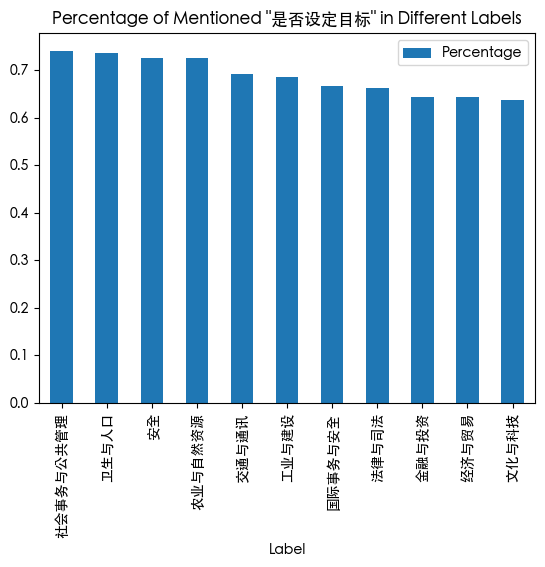

In [18]:
# we use l1 to aggregate the result
agg_result = etrieve_info_length = df_all.groupby('label_L1')

data = []
for name, group in agg_result:
    total = group['Retrieve Info Length'].count()
    mention = group[group['Retrieve Info Length'] != 0]['Retrieve Info Length'].count()
    data.append((name, mention, total, mention/total))

data.sort(key=lambda x: x[3], reverse=True)

# plot the result so we can see the percentage of the mention in different labels
df_plot = pd.DataFrame(data, columns=['Label', 'Mention', 'Total', 'Percentage'])
df_plot.plot(x='Label', y='Percentage', kind='bar')
plt.title('Percentage of Mentioned "是否设定目标" in Different Labels')
plt.xticks(rotation=90)
plt.show()

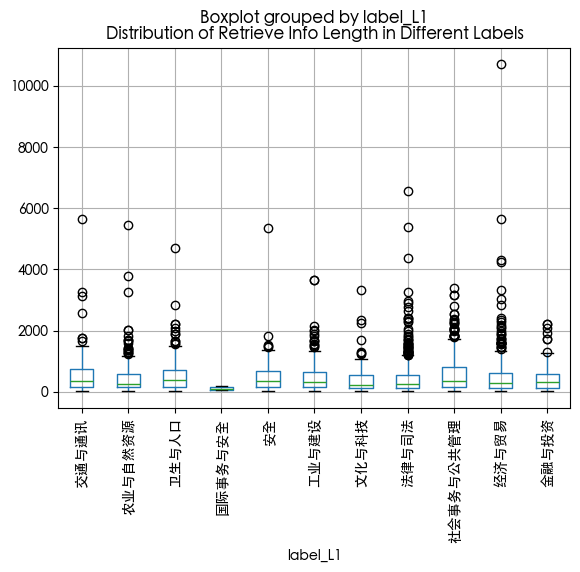

In [19]:
# we can also plot box plot to show the distribution of retrieve info length in different labels
df_temp = df_all.copy()
# we drop all the rows that do not have retrieve info
df_temp = df_temp[df_temp['Retrieve Info'] != '']
df_temp.boxplot(column='Retrieve Info Length', by='label_L1')
plt.title('Distribution of Retrieve Info Length in Different Labels')
plt.xticks(rotation=90)
plt.show()

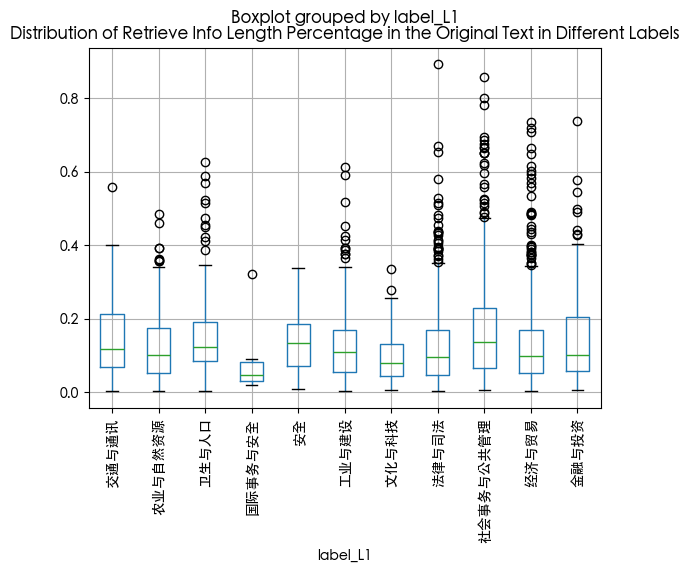

In [20]:
# we can also show the distribution that to what percentage of the document is the retrieve info in different labels
df_temp['Retrieve Info Length Percentage'] = df_temp['Retrieve Info Length'] / df_temp['Original Text Length']
df_temp.boxplot(column='Retrieve Info Length Percentage', by='label_L1')
plt.title('Distribution of Retrieve Info Length Percentage in the Original Text in Different Labels')
plt.xticks(rotation=90)
plt.show()